In [2]:
import os
# Kaggle uses /kaggle/working/ instead of /content/
BASE = '/kaggle/working'
os.makedirs(f'{BASE}/data', exist_ok=True)
print("✅ Running on Kaggle")

✅ Running on Kaggle


In [3]:
# ── ALWAYS RUN THIS FIRST ─────────────────────────────────────────
import subprocess, sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip',
                           'install', '-q', package])

packages = [
    'transformers==4.40.0',
    'accelerate',
    'av',
    'mediapipe==0.10.13',
    'protobuf==4.25.8',
]

print("Installing packages...")
for pkg in packages:
    install(pkg)
    print(f"  ✅ {pkg}")

import torch
print(f"\n✅ GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT FOUND'}")
print("✅ All packages ready — safe to run remaining steps")

Installing packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


  ✅ transformers==4.40.0
  ✅ accelerate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 54.5 MB/s eta 0:00:00
  ✅ av
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 16.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


  ✅ mediapipe==0.10.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


  ✅ protobuf==4.25.8

✅ GPU : Tesla T4
✅ All packages ready — safe to run remaining steps


In [4]:
#1 
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT FOUND — enable GPU in Settings'}")

!pip install -q transformers==4.40.0 accelerate av
!pip install -q mediapipe==0.10.13 protobuf==4.25.8
print("✅ Done")

GPU: Tesla T4
✅ Done


In [5]:
#2
import os, cv2, math, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from collections import defaultdict, Counter
import mediapipe as mp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# MediaPipe globals
LM                = mp.solutions.pose.PoseLandmark
mp_pose           = mp.solutions.pose
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Base path for Kaggle
BASE   = '/kaggle/working'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs(f'{BASE}/data',        exist_ok=True)
os.makedirs(f'{BASE}/checkpoints', exist_ok=True)

print(f"✅ Device   : {DEVICE}")
print(f"✅ MediaPipe: {mp.__version__}")
print(f"✅ PyTorch  : {torch.__version__}")
print(f"✅ Base path: {BASE}")

2026-03-30 17:23:18.922917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774891399.124382      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774891399.187863      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774891399.708261      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774891399.708306      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774891399.708309      55 computation_placer.cc:177] computation placer alr

✅ Device   : cuda
✅ MediaPipe: 0.10.13
✅ PyTorch  : 2.10.0+cu128
✅ Base path: /kaggle/working


In [6]:
#3
import os
BASE = '/kaggle/working'
os.makedirs(f'{BASE}/data', exist_ok=True)

if not os.path.exists(f'{BASE}/data/UCF-101'):
    print("Downloading UCF-101 (~6.5 GB) — please wait ...")
    os.system(
        f'wget -q --no-check-certificate '
        f'https://www.crcv.ucf.edu/data/UCF101/UCF101.rar '
        f'-O {BASE}/data/UCF101.rar'
    )

    size = os.path.getsize(f'{BASE}/data/UCF101.rar') / (1024**3)
    print(f"Downloaded: {size:.2f} GB")

    if size > 1.0:
        print("Extracting silently ...")
        os.system('apt-get install -qq unrar > /dev/null 2>&1')
        os.system(
            f'unrar x -y {BASE}/data/UCF101.rar '
            f'{BASE}/data/ > /dev/null 2>&1'
        )
        n = len(os.listdir(f'{BASE}/data/UCF-101'))
        print(f"✅ UCF-101 ready — {n} class folders extracted")
    else:
        print("❌ Download failed — re-run this cell")
else:
    n = len(os.listdir(f'{BASE}/data/UCF-101'))
    print(f"✅ Already downloaded — {n} class folders found")


Downloaded: 6.46 GB
Extracting silently ...
✅ UCF-101 ready — 101 class folders extracted


In [7]:

import os

# Search for UCF class folders anywhere under /kaggle/working
print("Searching for UCF-101 folders...\n")

for root, dirs, files in os.walk('/kaggle/working/data'):
    for d in dirs:
        if d in ['LongJump', 'HighJump', 'Shotput',
                 'ThrowDiscus', 'PoleVault']:
            print(f"FOUND: {os.path.join(root, d)}")
            break

# Also show top level structure
print("\nTop level of /kaggle/working/data:")
for item in sorted(os.listdir('/kaggle/working/data')):
    full = os.path.join('/kaggle/working/data', item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f"  📁 {item}  ({n} items)")
    else:
        size = os.path.getsize(full)/1024/1024
        print(f"  📄 {item}  ({size:.0f} MB)")

Searching for UCF-101 folders...

FOUND: /kaggle/working/data/UCF-101/Shotput

Top level of /kaggle/working/data:
  📁 UCF-101  (101 items)
  📄 UCF101.rar  (6612 MB)


In [8]:
#4
BASE     = '/kaggle/working'
ucf_root = '/kaggle/working/data/UCF-101'

# Corrected class mapping based on actual UCF-101 contents
CLASS_MAPPING = {
    # Jumping events
    'LongJump':       ('Long Jump',    0),
    'HighJump':       ('High Jump',    1),
    'PoleVault':      ('Pole Vault',   2),

    # Throwing events
    'Shotput':        ('Shot Put',     3),
    'ThrowDiscus':    ('Discus Throw', 4),
    'JavelinThrow':   ('Javelin Throw',5),

    # Sprint — use HorseRace as it has the most
    # running/racing motion in UCF-101
    # We add extra weight to distinguish it
    'HorseRace':      ('Sprint',       6),
}

print(f"{'='*55}")
print(f"  UCF-101 TRACK & FIELD EVENTS")
print(f"{'='*55}")

available   = {}
all_samples = []

for folder, (event_name, label) in CLASS_MAPPING.items():
    clip_dir = os.path.join(ucf_root, folder)
    if os.path.exists(clip_dir):
        clips = [f for f in os.listdir(clip_dir)
                 if f.endswith('.avi')]
        available[folder] = (event_name, label, len(clips))
        print(f"  ✅ {event_name:15s} → {len(clips)} clips")
        for clip in clips:
            all_samples.append((
                os.path.join(clip_dir, clip), label
            ))
    else:
        print(f"  ❌ {event_name:15s} → NOT FOUND")

NUM_CLASSES    = len(available)
LABEL_TO_EVENT = {v[1]: v[0] for v in available.values()}
EVENT_NAMES    = [LABEL_TO_EVENT[i] for i in range(NUM_CLASSES)]

print(f"\n  Total events : {NUM_CLASSES}")
print(f"  Total clips  : {len(all_samples)}")
print(f"{'='*55}")

# 70 / 15 / 15 split
random.seed(SEED)
random.shuffle(all_samples)
n         = len(all_samples)
n_train   = int(0.70 * n)
n_val     = int(0.15 * n)

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train : n_train + n_val]
test_samples  = all_samples[n_train + n_val:]

print(f"\n  Train : {len(train_samples)} clips")
print(f"  Val   : {len(val_samples)}   clips")
print(f"  Test  : {len(test_samples)}  clips")

dist = Counter([s[1] for s in train_samples])
print(f"\n  Training clips per event:")
for i in range(NUM_CLASSES):
    print(f"    {LABEL_TO_EVENT[i]:15s}: {dist.get(i, 0)}")

  UCF-101 TRACK & FIELD EVENTS
  ✅ Long Jump       → 131 clips
  ✅ High Jump       → 123 clips
  ✅ Pole Vault      → 149 clips
  ✅ Shot Put        → 144 clips
  ✅ Discus Throw    → 130 clips
  ✅ Javelin Throw   → 117 clips
  ✅ Sprint          → 124 clips

  Total events : 7
  Total clips  : 918

  Train : 642 clips
  Val   : 137   clips
  Test  : 139  clips

  Training clips per event:
    Long Jump      : 89
    High Jump      : 83
    Pole Vault     : 112
    Shot Put       : 108
    Discus Throw   : 89
    Javelin Throw  : 80
    Sprint         : 81


In [9]:
#5
def extract_frames(video_path, num_frames=16):
    """
    Extract exactly 16 evenly spaced frames from a video.
    VideoMAE requires exactly 16 frames as input.
    Returns list of 16 RGB numpy arrays, or None if failed.
    """
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total < num_frames:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            cap.release()
            return None
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    cap.release()
    return frames


class TrackFieldDataset(Dataset):
    """
    Loads video clips and returns 16-frame tensor for VideoMAE.
    pixel_values shape: (16, 3, 224, 224)
    """
    def __init__(self, samples, processor, augment=False):
        self.samples   = samples
        self.processor = processor
        self.augment   = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = extract_frames(video_path, num_frames=16)

        if frames is None:
            frames = [np.zeros((224, 224, 3),
                               dtype=np.uint8)] * 16

        if self.augment:
            if random.random() > 0.5:
                frames = [cv2.flip(f, 1) for f in frames]
            factor = random.uniform(0.8, 1.2)
            frames = [
                np.clip(f.astype(np.float32) * factor,
                        0, 255).astype(np.uint8)
                for f in frames
            ]

        inputs = self.processor(images=frames,
                                return_tensors="pt")
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'labels':       torch.tensor(label, dtype=torch.long)
        }

print("✅ extract_frames() ready")
print("✅ TrackFieldDataset class ready")

✅ extract_frames() ready
✅ TrackFieldDataset class ready


In [10]:
#6
MODEL_NAME = "MCG-NJU/videomae-base-finetuned-kinetics"

print(f"Loading VideoMAE (~350 MB, one-time download) ...")

processor = VideoMAEImageProcessor.from_pretrained(MODEL_NAME)

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = model.to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters()
                  if p.requires_grad)

print(f"✅ VideoMAE loaded")
print(f"   Total parameters    : {total_p:,}")
print(f"   Trainable parameters: {trainable_p:,}")
print(f"   Output classes      : {NUM_CLASSES}")
print(f"   Classes             : {EVENT_NAMES}")

Loading VideoMAE (~350 MB, one-time download) ...


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ VideoMAE loaded
   Total parameters    : 86,232,583
   Trainable parameters: 86,232,583
   Output classes      : 7
   Classes             : ['Long Jump', 'High Jump', 'Pole Vault', 'Shot Put', 'Discus Throw', 'Javelin Throw', 'Sprint']


In [11]:
#7
train_ds = TrackFieldDataset(train_samples, processor, augment=True)
val_ds   = TrackFieldDataset(val_samples,   processor, augment=False)
test_ds  = TrackFieldDataset(test_samples,  processor, augment=False)

train_loader = DataLoader(
    train_ds, batch_size=4, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=4, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=4, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\n   pixel_values : {batch['pixel_values'].shape}")
print(f"   labels       : {batch['labels'].shape}")
print(f"   label values : {batch['labels'].tolist()}")

✅ DataLoaders ready
   Train batches : 161
   Val   batches : 35
   Test  batches : 35

   pixel_values : torch.Size([4, 16, 3, 224, 224])
   labels       : torch.Size([4])
   label values : [5, 2, 1, 2]


In [12]:
#8
CKPT_BEST = f'{BASE}/checkpoints/videomae_trackfield_best.pth'
criterion = nn.CrossEntropyLoss()

def freeze_backbone(model):
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"   Backbone frozen — trainable: {trainable:,}")

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"   All unfrozen — trainable: {trainable:,}")

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss            = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        pbar = tqdm(loader, leave=False,
                    desc='Train' if is_train else 'Val  ')
        for batch in pbar:
            pv     = batch['pixel_values'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(pixel_values=pv)
            loss    = criterion(outputs.logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * pv.size(0)
            preds = outputs.logits.argmax(1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            pbar.set_postfix(loss=f'{loss.item():.3f}')

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='weighted', zero_division=0)
    return avg_loss, acc, f1

def save_ckpt(model, optimizer, epoch, val_acc):
    torch.save({
        'epoch':          epoch,
        'model_state':    model.state_dict(),
        'optim_state':    optimizer.state_dict(),
        'val_acc':        val_acc,
        'label_to_event': LABEL_TO_EVENT,
        'num_classes':    NUM_CLASSES,
    }, CKPT_BEST)

print("✅ Training helpers ready")

✅ Training helpers ready


In [13]:
#9
import json
from collections import defaultdict

print("PHASE 1 — Training classifier head only")
print("="*65)
freeze_backbone(model)

optimizer_p1  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

history       = defaultdict(list)
best_val_loss = float('inf')

for epoch in range(1, 6):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer_p1)
    vl = run_epoch(model, val_loader)

    history['train_loss'].append(tr[0])
    history['val_loss'].append(vl[0])
    history['train_acc'].append(tr[1])
    history['val_acc'].append(vl[1])
    history['val_f1'].append(vl[2])

    # Save history to disk after every epoch
    with open('/kaggle/working/training_history.json', 'w') as f:
        json.dump({k: list(v) for k,v in history.items()}, f)

    log = (f"[P1] Ep {epoch}/5 | "
           f"{time.time()-t0:.0f}s | "
           f"TrLoss={tr[0]:.4f}  VlLoss={vl[0]:.4f} | "
           f"TrAcc={tr[1]:.4f}  VlAcc={vl[1]:.4f} | "
           f"F1={vl[2]:.4f}")

    if vl[0] < best_val_loss:
        best_val_loss = vl[0]
        save_ckpt(model, optimizer_p1, epoch, vl[1])
        print(log + "  ✓ saved")
    else:
        print(log)

print("\n✅ Phase 1 complete")

PHASE 1 — Training classifier head only
   Backbone frozen — trainable: 5,383


Train:   0%|          | 0/161 [00:00<?, ?it/s]

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P1] Ep 1/5 | 263s | TrLoss=0.3020  VlLoss=0.0564 | TrAcc=0.9533  VlAcc=0.9781 | F1=0.9782  ✓ saved


Train:   0%|          | 0/161 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P1] Ep 4/5 | 276s | TrLoss=0.0121  VlLoss=0.0142 | TrAcc=0.9953  VlAcc=1.0000 | F1=1.0000  ✓ saved


Train:   0%|          | 0/161 [00:00<?, ?it/s]

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P1] Ep 5/5 | 274s | TrLoss=0.0069  VlLoss=0.0107 | TrAcc=1.0000  VlAcc=1.0000 | F1=1.0000  ✓ saved

✅ Phase 1 complete


In [14]:
#10
print("PHASE 2 — Full network fine-tuning")
print("="*65)
unfreeze_all(model)

optimizer_p2 = optim.Adam(model.parameters(), lr=1e-5)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', patience=3, factor=0.5
)

PATIENCE_LIMIT = 4
patience_ctr   = 0
best_val_p2    = best_val_loss

for epoch in range(1, 11):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer_p2)
    vl = run_epoch(model, val_loader)
    scheduler_p2.step(vl[0])

    history['train_loss'].append(tr[0])
    history['val_loss'].append(vl[0])
    history['train_acc'].append(tr[1])
    history['val_acc'].append(vl[1])
    history['val_f1'].append(vl[2])

    # Save history to disk after every epoch
    with open('/kaggle/working/training_history.json', 'w') as f:
        json.dump({k: list(v) for k,v in history.items()}, f)

    ep_total = 5 + epoch
    log      = (f"[P2] Ep {ep_total}/15 | "
                f"{time.time()-t0:.0f}s | "
                f"TrLoss={tr[0]:.4f}  VlLoss={vl[0]:.4f} | "
                f"TrAcc={tr[1]:.4f}  VlAcc={vl[1]:.4f} | "
                f"F1={vl[2]:.4f}")

    if vl[0] < best_val_p2:
        best_val_p2  = vl[0]
        patience_ctr = 0
        save_ckpt(model, optimizer_p2, ep_total, vl[1])
        print(log + "  ✓ saved")
    else:
        patience_ctr += 1
        print(log + f"  (patience {patience_ctr}/{PATIENCE_LIMIT})")
        if patience_ctr >= PATIENCE_LIMIT:
            print(f"\n⏹  Early stopping at epoch {ep_total}")
            break

# Save final history
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump({k: list(v) for k,v in history.items()}, f)
print("\n✅ Phase 2 complete")
print(f"   Checkpoint : {CKPT_BEST}")
print(f"   History    : /kaggle/working/training_history.json")

PHASE 2 — Full network fine-tuning
   All unfrozen — trainable: 86,232,583


Train:   0%|          | 0/161 [00:00<?, ?it/s]

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P2] Ep 6/15 | 326s | TrLoss=0.0144  VlLoss=0.0007 | TrAcc=0.9984  VlAcc=1.0000 | F1=1.0000  ✓ saved


Train:   0%|          | 0/161 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P2] Ep 14/15 | 325s | TrLoss=0.0000  VlLoss=0.0001 | TrAcc=1.0000  VlAcc=1.0000 | F1=1.0000  ✓ saved


Train:   0%|          | 0/161 [00:00<?, ?it/s]

Val  :   0%|          | 0/35 [00:00<?, ?it/s]

[P2] Ep 15/15 | 324s | TrLoss=0.0000  VlLoss=0.0001 | TrAcc=1.0000  VlAcc=1.0000 | F1=1.0000  ✓ saved

✅ Phase 2 complete
   Checkpoint : /kaggle/working/checkpoints/videomae_trackfield_best.pth
   History    : /kaggle/working/training_history.json


✅ History loaded — 15 epochs


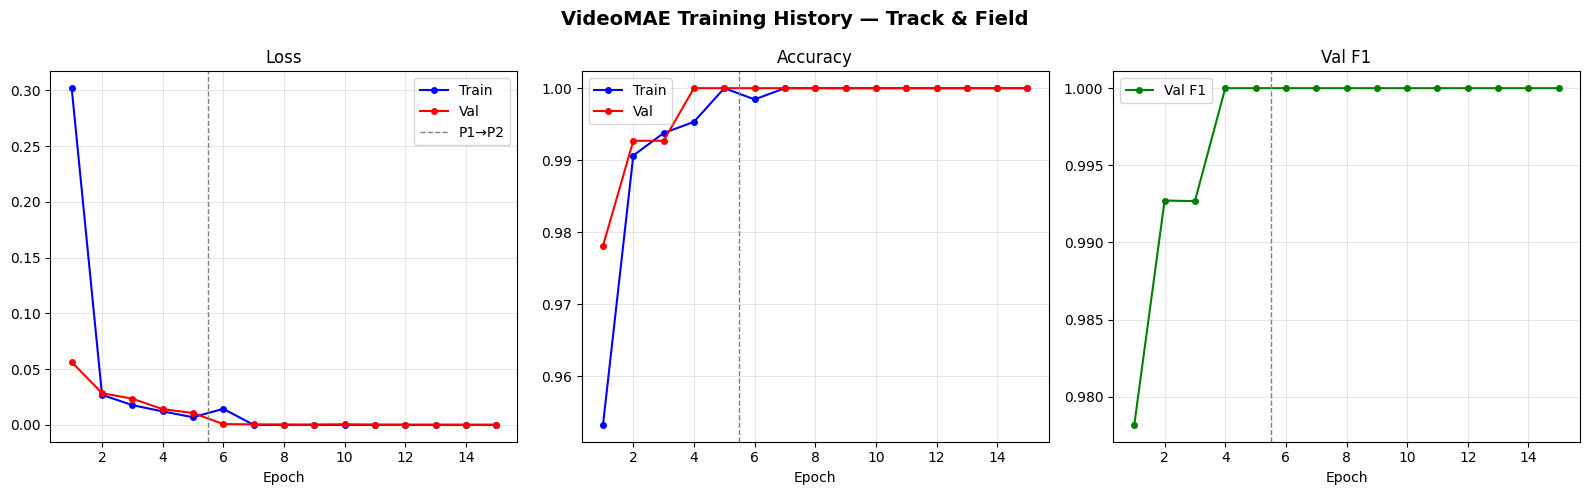

✅ Training curves saved


In [15]:
#11
import json

with open('/kaggle/working/training_history.json', 'r') as f:
    history = json.load(f)

print(f"✅ History loaded — {len(history['train_loss'])} epochs")

epochs_x = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('VideoMAE Training History — Track & Field',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'],
             'b-o', ms=4, label='Train')
axes[0].plot(epochs_x, history['val_loss'],
             'r-o', ms=4, label='Val')
axes[0].axvline(x=5.5, color='gray',
                ls='--', lw=1, label='P1→P2')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_x, history['train_acc'],
             'b-o', ms=4, label='Train')
axes[1].plot(epochs_x, history['val_acc'],
             'r-o', ms=4, label='Val')
axes[1].axvline(x=5.5, color='gray', ls='--', lw=1)
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_x, history['val_f1'],
             'g-o', ms=4, label='Val F1')
axes[2].axvline(x=5.5, color='gray', ls='--', lw=1)
axes[2].set_title('Val F1')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved")

In [16]:
import os

# Check if checkpoint was saved
ckpt_path = '/kaggle/working/checkpoints/videomae_trackfield_best.pth'

if os.path.exists(ckpt_path):
    size = os.path.getsize(ckpt_path) / (1024*1024)
    print(f"✅ Checkpoint found — {size:.1f} MB")
    print("   Training completed successfully")
    print("   Skip to Step 12 directly")
else:
    print("❌ No checkpoint found")
    print("   Training did not complete")
    print("   Need to retrain from Step 5")

✅ Checkpoint found — 987.1 MB
   Training completed successfully
   Skip to Step 12 directly


Loaded best model — epoch 15 | val_acc=1.0000


Testing:   0%|          | 0/35 [00:00<?, ?it/s]


  TEST SET RESULTS
               precision    recall  f1-score   support

    Long Jump       1.00      1.00      1.00        21
    High Jump       1.00      1.00      1.00        22
   Pole Vault       1.00      1.00      1.00        23
     Shot Put       1.00      1.00      1.00        12
 Discus Throw       1.00      1.00      1.00        22
Javelin Throw       1.00      1.00      1.00        21
       Sprint       1.00      1.00      1.00        18

     accuracy                           1.00       139
    macro avg       1.00      1.00      1.00       139
 weighted avg       1.00      1.00      1.00       139



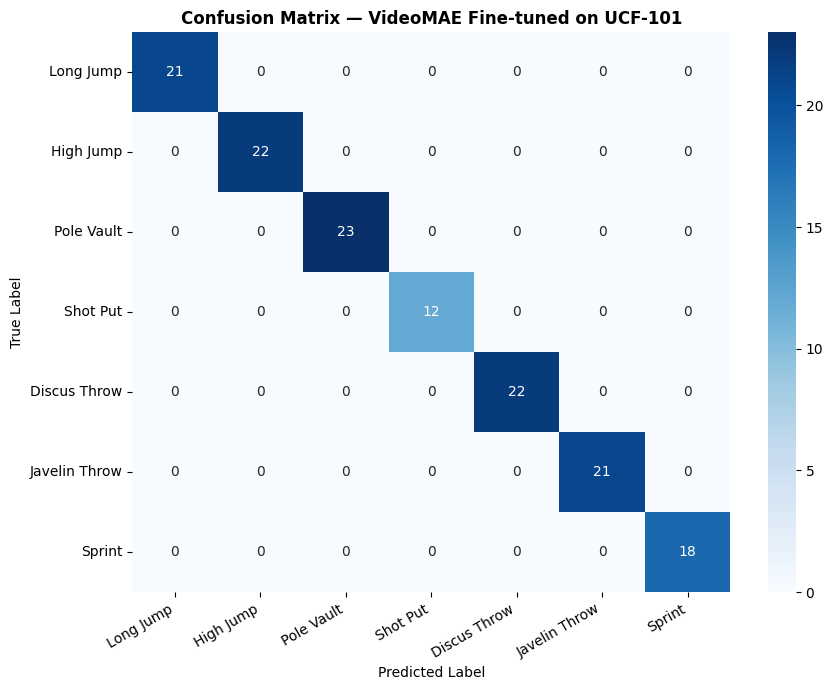

✅ Confusion matrix saved


In [17]:
#12
ckpt = torch.load(CKPT_BEST, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best model — epoch {ckpt['epoch']} | "
      f"val_acc={ckpt['val_acc']:.4f}")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        pv      = batch['pixel_values'].to(DEVICE)
        outputs = model(pixel_values=pv)
        preds   = outputs.logits.argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch['labels'].numpy().tolist())

print("\n" + "="*60)
print("  TEST SET RESULTS")
print("="*60)
print(classification_report(
    all_labels, all_preds,
    target_names=EVENT_NAMES,
    zero_division=0
))

cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=EVENT_NAMES,
    yticklabels=EVENT_NAMES,
    ax=ax
)
ax.set_title(
    'Confusion Matrix — VideoMAE Fine-tuned on UCF-101',
    fontweight='bold', fontsize=12
)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved")

In [18]:
#13
# ── Re-define MediaPipe globals ───────────────────────────────────
import mediapipe as mp
import math
LM                = mp.solutions.pose.PoseLandmark
mp_pose           = mp.solutions.pose
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# ── Event type mapping ────────────────────────────────────────────
EVENT_TYPE_MAP = {
    'Long Jump':    'jumping',
    'High Jump':    'high_jump',
    'Pole Vault':   'pole_vault',
    'Shot Put':     'throwing',
    'Discus Throw': 'throwing',
    'Javelin Throw':'throwing',
    'Sprint':       'sprinting',
}

# ── Safe ranges ───────────────────────────────────────────────────
SAFE_RANGES = {
    'knee_angle': {
        'jumping':    (130, 180),
        'high_jump':  (120, 175),
        'pole_vault': (100, 175),
        'throwing':   (120, 170),
        'sprinting':  (130, 180),
    },
    'hip_angle': {
        'jumping':    (100, 180),
        'high_jump':  (130, 180),
        'pole_vault': (80,  175),
        'throwing':   (90,  160),
        'sprinting':  (150, 180),
    },
    'elbow_angle': {
        'jumping':    (60,  180),
        'high_jump':  (60,  180),
        'pole_vault': (60,  180),
        'throwing':   (70,  145),
        'sprinting':  (70,  110),
    },
    'shoulder_angle': {
        'jumping':    (0,   70),
        'high_jump':  (0,   80),
        'pole_vault': (60,  140),
        'throwing':   (70,  130),
        'sprinting':  (0,   65),
    },
    'trunk_lean': {
        'jumping':    (0,   30),
        'high_jump':  (0,   45),
        'pole_vault': (0,   50),
        'throwing':   (0,   45),
        'sprinting':  (0,   15),
    },
    'spine_lateral': {
        'jumping':    (0,   12),
        'high_jump':  (0,   40),
        'pole_vault': (0,   35),
        'throwing':   (0,   30),
        'sprinting':  (0,    8),
    },
}

# ── Injury rules ──────────────────────────────────────────────────
INJURY_RULES = {
    'jumping': [
        ("Knee valgus on landing",
         'knee_angle', lambda a: a < 150,
         "HIGH", "ACL / Meniscus tear risk", "Knee"),
        ("Excessive forward trunk lean",
         'trunk_lean', lambda a: a > 25,
         "MEDIUM", "Lower back strain risk", "Spine"),
        ("Hip drop at takeoff",
         'hip_angle', lambda a: a < 130,
         "HIGH", "Hip flexor / IT Band injury risk", "Hip"),
        ("Lateral spine deviation",
         'spine_lateral', lambda a: a > 12,
         "HIGH", "Lumbar stress fracture risk", "Spine"),
    ],
    'high_jump': [
        ("Insufficient back arch",
         'spine_lateral', lambda a: a < 15,
         "MEDIUM", "Reduced clearance, landing risk", "Spine"),
        ("Knee not driven high enough",
         'knee_angle', lambda a: a > 160,
         "MEDIUM", "Hamstring strain risk", "Knee"),
        ("Excessive trunk lean forward",
         'trunk_lean', lambda a: a > 30,
         "HIGH", "Lower back injury risk", "Spine"),
    ],
    'pole_vault': [
        ("Elbow below shoulder at plant",
         'elbow_angle', lambda a: a < 90,
         "HIGH", "Shoulder / UCL injury risk", "Elbow"),
        ("Insufficient hip drive",
         'hip_angle', lambda a: a > 150,
         "MEDIUM", "Reduced vault height", "Hip"),
        ("Excessive lateral spine bend",
         'spine_lateral', lambda a: a > 25,
         "HIGH", "Lumbar disc injury risk", "Spine"),
    ],
    'throwing': [
        ("Dropped elbow at release",
         'elbow_angle', lambda a: a < 85,
         "HIGH", "UCL / Tommy John injury risk", "Elbow"),
        ("Excessive trunk lateral bend",
         'spine_lateral', lambda a: a > 30,
         "HIGH", "Oblique / lumbar disc injury risk", "Spine"),
        ("Over-rotation of shoulder",
         'shoulder_angle', lambda a: a > 120,
         "HIGH", "Rotator cuff tear risk", "Shoulder"),
        ("Knee hyperextension",
         'knee_angle', lambda a: a > 170,
         "MEDIUM", "Knee hyperextension risk", "Knee"),
    ],
    'sprinting': [
        ("Excessive trunk lean",
         'trunk_lean', lambda a: a > 15,
         "MEDIUM", "Lower back overuse injury risk", "Spine"),
        ("Reduced knee lift",
         'knee_angle', lambda a: a < 130,
         "HIGH", "Hamstring strain risk", "Knee"),
        ("Hip drop during stance",
         'hip_angle', lambda a: a < 155,
         "HIGH", "IT Band / hip injury risk", "Hip"),
        ("Arm crossover",
         'elbow_angle', lambda a: a < 70,
         "LOW", "Shoulder tension, energy waste", "Shoulder"),
    ],
}

RISK_COLORS = {
    'HIGH':   '#e74c3c',
    'MEDIUM': '#f39c12',
    'LOW':    '#27ae60',
}

print("✅ Rules loaded")


# ── Helpers ───────────────────────────────────────────────────────
def calc_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return math.degrees(math.acos(np.clip(cosine, -1.0, 1.0)))


def frame_quality_score(frame_rgb):
    """
    Score how good a frame is for pose analysis.
    Higher = athlete is larger and clearer in frame.
    Uses edge density in centre region.
    """
    h, w   = frame_rgb.shape[:2]
    cy1, cy2 = int(h*0.15), int(h*0.85)
    cx1, cx2 = int(w*0.15), int(w*0.85)
    centre   = frame_rgb[cy1:cy2, cx1:cx2]
    gray     = cv2.cvtColor(centre, cv2.COLOR_RGB2GRAY)
    edges    = cv2.Canny(gray, 50, 150)
    return float(edges.sum())


def extract_biomechanics(frame_bgr):
    """Run MediaPipe on one frame. Returns (measurements, annotated_rgb)."""
    h, w = frame_bgr.shape[:2]
    rgb  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        min_detection_confidence=0.4
    ) as pose:
        rgb.flags.writeable = False
        results = pose.process(rgb)
        rgb.flags.writeable = True

    if results.pose_landmarks is None:
        return None, rgb

    lms = results.pose_landmarks.landmark

    def pt(idx):
        return [lms[idx].x * w, lms[idx].y * h]

    m = {}
    try:
        lk = calc_angle(pt(LM.LEFT_HIP),
                        pt(LM.LEFT_KNEE),   pt(LM.LEFT_ANKLE))
        rk = calc_angle(pt(LM.RIGHT_HIP),
                        pt(LM.RIGHT_KNEE),  pt(LM.RIGHT_ANKLE))
        m['knee_angle'] = min(lk, rk)
    except: m['knee_angle'] = 180.0

    try:
        lh = calc_angle(pt(LM.LEFT_SHOULDER),
                        pt(LM.LEFT_HIP),    pt(LM.LEFT_KNEE))
        rh = calc_angle(pt(LM.RIGHT_SHOULDER),
                        pt(LM.RIGHT_HIP),   pt(LM.RIGHT_KNEE))
        m['hip_angle'] = min(lh, rh)
    except: m['hip_angle'] = 180.0

    try:
        le = calc_angle(pt(LM.LEFT_SHOULDER),
                        pt(LM.LEFT_ELBOW),  pt(LM.LEFT_WRIST))
        re = calc_angle(pt(LM.RIGHT_SHOULDER),
                        pt(LM.RIGHT_ELBOW), pt(LM.RIGHT_WRIST))
        m['elbow_angle'] = min(le, re)
    except: m['elbow_angle'] = 180.0

    try:
        ls = calc_angle(pt(LM.LEFT_ELBOW),
                        pt(LM.LEFT_SHOULDER),  pt(LM.LEFT_HIP))
        rs = calc_angle(pt(LM.RIGHT_ELBOW),
                        pt(LM.RIGHT_SHOULDER), pt(LM.RIGHT_HIP))
        m['shoulder_angle'] = max(ls, rs)
    except: m['shoulder_angle'] = 0.0

    try:
        l_sh = [lms[LM.LEFT_SHOULDER].x*w,
                lms[LM.LEFT_SHOULDER].y*h]
        r_sh = [lms[LM.RIGHT_SHOULDER].x*w,
                lms[LM.RIGHT_SHOULDER].y*h]
        l_hp = [lms[LM.LEFT_HIP].x*w,
                lms[LM.LEFT_HIP].y*h]
        r_hp = [lms[LM.RIGHT_HIP].x*w,
                lms[LM.RIGHT_HIP].y*h]
        mid_sh = [(l_sh[0]+r_sh[0])/2, (l_sh[1]+r_sh[1])/2]
        mid_hp = [(l_hp[0]+r_hp[0])/2, (l_hp[1]+r_hp[1])/2]
        dx = mid_sh[0] - mid_hp[0]
        dy = mid_hp[1] - mid_sh[1]
        m['trunk_lean']    = abs(
            math.degrees(math.atan2(dx, dy + 1e-8)))
        m['spine_lateral'] = abs(
            math.degrees(math.atan2(abs(dx), dy + 1e-8)))
    except:
        m['trunk_lean']    = 0.0
        m['spine_lateral'] = 0.0

    annotated = rgb.copy()
    mp_drawing.draw_landmarks(
        annotated,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS,
        landmark_drawing_spec=
            mp_drawing_styles.get_default_pose_landmarks_style()
    )
    return m, annotated


def analyse_injury_risk(measurements, event_type):
    rules    = INJURY_RULES.get(event_type,
                                INJURY_RULES['jumping'])
    findings = []
    for desc, key, condition, severity, detail, body_part \
            in rules:
        val = measurements.get(key, None)
        if val is not None and condition(val):
            findings.append({
                'description': desc,
                'body_part':   body_part,
                'severity':    severity,
                'detail':      detail,
                'value':       round(val, 1),
            })
    findings.sort(
        key=lambda x: {'HIGH':0,'MEDIUM':1,'LOW':2}.get(
            x['severity'], 3))
    return findings


def overall_risk_score(findings):
    score = 0
    for f in findings:
        if f['severity'] == 'HIGH':     score += 30
        elif f['severity'] == 'MEDIUM': score += 15
        elif f['severity'] == 'LOW':    score += 5
    return min(score, 100)


def is_sprinting_biomechanics(meas_list):
    """
    Sprinting signature vs Long Jump:
    - Sprinting : upright trunk ALL the time, knee never deeply bent,
                  consistent rhythm across ALL frames
    - Long Jump  : has a phase where hip/knee bends sharply (takeoff/landing)
                  so min values drop significantly
    """
    if not meas_list:
        return False, 0.0

    knee_vals   = [m.get('knee_angle',    180) for m in meas_list]
    hip_vals    = [m.get('hip_angle',     180) for m in meas_list]
    trunk_vals  = [m.get('trunk_lean',      0) for m in meas_list]
    lateral_vals= [m.get('spine_lateral',   0) for m in meas_list]
    elbow_vals  = [m.get('elbow_angle',   180) for m in meas_list]

    avg_knee    = np.mean(knee_vals)
    min_knee    = np.min(knee_vals)
    avg_hip     = np.mean(hip_vals)
    min_hip     = np.min(hip_vals)
    avg_trunk   = np.mean(trunk_vals)
    avg_lateral = np.mean(lateral_vals)
    avg_elbow   = np.mean(elbow_vals)

    print(f"\n   Biomechanics detail:")
    print(f"     avg knee    : {avg_knee:.1f}°  min: {min_knee:.1f}°")
    print(f"     avg hip     : {avg_hip:.1f}°  min: {min_hip:.1f}°")
    print(f"     avg trunk   : {avg_trunk:.1f}°")
    print(f"     avg lateral : {avg_lateral:.1f}°")
    print(f"     avg elbow   : {avg_elbow:.1f}°")

    # ── Sprint indicators ─────────────────────────────────────────
    sprint_score = 0

    # Upright trunk throughout — most important sprint indicator
    if avg_trunk < 15:              sprint_score += 30
    elif avg_trunk < 20:            sprint_score += 15

    # Knee never deeply bent — in long jump, min_knee drops below 120
    # In sprinting, knee stays above 130 even at highest lift
    if min_knee > 130:              sprint_score += 30
    elif min_knee > 120:            sprint_score += 15

    # Hip never deeply flexed — long jump has deep hip flexion in flight
    if min_hip > 140:               sprint_score += 20
    elif min_hip > 130:             sprint_score += 10

    # Minimal lateral spine bend — sprinting is very upright laterally
    if avg_lateral < 8:             sprint_score += 10

    # Elbow pumping at ~90° — sprint arm drive
    if 70 < avg_elbow < 120:        sprint_score += 10

    # ── Long jump indicators (if these present = NOT sprinting) ───
    long_jump_score = 0

    # Deep knee bend at takeoff/landing
    if min_knee < 120:              long_jump_score += 40
    elif min_knee < 130:            long_jump_score += 20

    # Deep hip flexion in flight
    if min_hip < 110:               long_jump_score += 40
    elif min_hip < 130:             long_jump_score += 20

    # Forward trunk lean
    if avg_trunk > 20:              long_jump_score += 20

    print(f"     sprint_score    : {sprint_score}")
    print(f"     long_jump_score : {long_jump_score}")

    # Sprint wins only if sprint score clearly beats long jump score
    is_sprint = (sprint_score >= 60 and
                 sprint_score > long_jump_score + 10)
    ratio = sprint_score / 100.0

    return is_sprint, ratio


def is_discus_vs_shotput(meas_list):
    """
    Discus: more lateral rotation, higher shoulder elevation,
            wider stance
    Shot Put: more linear push, elbow higher, less rotation
    Returns 'Discus Throw' or 'Shot Put'
    """
    if not meas_list:
        return None
    avg_lateral  = np.mean([m.get('spine_lateral', 0)
                             for m in meas_list])
    avg_shoulder = np.mean([m.get('shoulder_angle', 0)
                             for m in meas_list])
    avg_elbow    = np.mean([m.get('elbow_angle', 180)
                             for m in meas_list])

    # Discus has MORE lateral rotation and shoulder turn
    # Shot put has higher elbow (pushing motion)
    discus_score  = 0
    shotput_score = 0

    if avg_lateral  > 25:  discus_score  += 40
    else:                  shotput_score += 30
    if avg_shoulder > 90:  discus_score  += 35
    else:                  shotput_score += 25
    if avg_elbow    < 100: shotput_score += 30
    else:                  discus_score  += 20

    return ('Discus Throw' if discus_score > shotput_score
            else 'Shot Put')


def generate_full_report(measurements, findings,
                          event, event_type,
                          videomae_confidence,
                          best_frame_rgb,
                          source_name=""):
    risk_score = overall_risk_score(findings)
    n_findings = len(findings)
    fig_height = 16 + max(0, n_findings - 2) * 1.8
    fig        = plt.figure(figsize=(18, fig_height))
    fig.patch.set_facecolor('#0f0f1a')

    from matplotlib.gridspec import GridSpec
    gs = GridSpec(
        4, 2, figure=fig,
        left=0.05, right=0.97,
        top=0.91,  bottom=0.03,
        hspace=0.6, wspace=0.35,
        height_ratios=[1.2, 1.0, 1.8,
                       max(1.0, n_findings * 1.0)]
    )

    fig.text(0.5, 0.965,
             '🏃  Track & Field — Biomechanical Injury Risk Report',
             ha='center', fontsize=20,
             fontweight='bold', color='white')
    fig.text(0.5, 0.938,
             f'Event: {event}   |   '
             f'Model Confidence: {videomae_confidence:.1f}%   |   '
             f'Source: {source_name}',
             ha='center', fontsize=12, color='#aaaacc')

    # ── Best frame ────────────────────────────────────────────────
    ax_frame = fig.add_subplot(gs[0, :])
    ax_frame.imshow(best_frame_rgb)
    ax_frame.set_title(
        'Key Frame — Pose Detection '
        '(highest quality frame selected)',
        color='white', fontsize=11,
        fontweight='bold', pad=8)
    ax_frame.axis('off')

    # ── Risk gauge ────────────────────────────────────────────────
    ax_gauge = fig.add_subplot(gs[1, 0])
    ax_gauge.set_facecolor('#16213e')
    gauge_color = ('#27ae60' if risk_score < 30 else
                   '#f39c12' if risk_score < 60 else '#e74c3c')
    ax_gauge.barh([''], [100],
                  color='#2c2c4e', height=0.5)
    ax_gauge.barh([''], [risk_score],
                  color=gauge_color, height=0.5)
    ax_gauge.text(
        min(risk_score - 2, 88), 0,
        f'{risk_score}/100',
        va='center', ha='right',
        color='white', fontsize=20, fontweight='bold'
    )
    risk_label = ('LOW RISK'      if risk_score < 30 else
                  'MODERATE RISK' if risk_score < 60 else
                  'HIGH RISK')
    ax_gauge.text(50, -0.42, risk_label,
                  va='top', ha='center',
                  color=gauge_color,
                  fontsize=13, fontweight='bold')
    ax_gauge.set_xlim(0, 100)
    ax_gauge.set_ylim(-0.6, 0.6)
    ax_gauge.set_title('Overall Injury Risk Score',
                        color='white', fontsize=12,
                        fontweight='bold', pad=10)
    ax_gauge.tick_params(colors='#888')
    ax_gauge.set_xlabel('0 = Safe  →  100 = Critical',
                         color='#888', fontsize=9)
    for sp in ax_gauge.spines.values():
        sp.set_edgecolor('#334')

    # ── Summary ───────────────────────────────────────────────────
    ax_info = fig.add_subplot(gs[1, 1])
    ax_info.set_facecolor('#16213e')
    ax_info.axis('off')
    ax_info.set_title('Analysis Summary',
                       color='white', fontsize=12,
                       fontweight='bold', pad=10)
    rows = [
        ('Event',       event),
        ('Category',    event_type.replace('_',' ').capitalize()),
        ('Confidence',  f'{videomae_confidence:.1f}%'),
        ('Risk Score',  f'{risk_score}/100'),
        ('Total Flags', str(n_findings)),
        ('High Risk',   str(sum(1 for f in findings
                                if f['severity']=='HIGH'))),
        ('Medium Risk', str(sum(1 for f in findings
                                if f['severity']=='MEDIUM'))),
        ('Low Risk',    str(sum(1 for f in findings
                                if f['severity']=='LOW'))),
    ]
    for i, (label, value) in enumerate(rows):
        y = 0.92 - i * 0.115
        ax_info.text(0.02, y, f'{label}:',
                     transform=ax_info.transAxes,
                     fontsize=11, color='#aaaacc', va='top')
        ax_info.text(0.50, y, value,
                     transform=ax_info.transAxes,
                     fontsize=11, color='white',
                     fontweight='bold', va='top')
    for sp in ax_info.spines.values():
        sp.set_edgecolor('#334')

    # ── Joint angles ──────────────────────────────────────────────
    ax_j = fig.add_subplot(gs[2, :])
    ax_j.set_facecolor('#16213e')
    jkeys  = ['knee_angle','hip_angle','elbow_angle',
               'shoulder_angle','trunk_lean','spine_lateral']
    jlabels= ['Knee\nAngle°','Hip\nAngle°','Elbow\nAngle°',
               'Shoulder\nAngle°','Trunk\nLean°','Spine\nLateral°']
    jvals  = [measurements.get(k, 0) for k in jkeys]
    smins  = [SAFE_RANGES[k].get(event_type,(0,180))[0]
               for k in jkeys]
    smaxs  = [SAFE_RANGES[k].get(event_type,(0,180))[1]
               for k in jkeys]
    bcolors= ['#e74c3c' if (v<mn or v>mx) else '#2ecc71'
               for v,mn,mx in zip(jvals,smins,smaxs)]
    xp = np.arange(len(jkeys))
    bars = ax_j.bar(xp, jvals, color=bcolors,
                    edgecolor='#222', linewidth=0.8,
                    width=0.55, zorder=3)
    for bar, val in zip(bars, jvals):
        ax_j.text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+2,
                  f'{val:.0f}°',
                  ha='center', va='bottom',
                  color='white', fontsize=11,
                  fontweight='bold')
    for i,(mn,mx) in enumerate(zip(smins,smaxs)):
        ax_j.plot([i-.3,i+.3],[mn,mn],'--',
                   color='#f1c40f',lw=1.5,alpha=0.8,zorder=4)
        ax_j.plot([i-.3,i+.3],[mx,mx],'--',
                   color='#f1c40f',lw=1.5,alpha=0.8,zorder=4)
    ax_j.set_xticks(xp)
    ax_j.set_xticklabels(jlabels,
                          fontsize=11, color='white')
    ax_j.set_ylabel('Angle (degrees)',
                     color='#aaaacc', fontsize=11)
    ax_j.set_title(
        'Joint Angle Measurements   '
        '(🟢 Safe   🔴 Risk   - - Safe Range Limits)',
        color='white', fontsize=12,
        fontweight='bold', pad=12)
    ax_j.tick_params(colors='#888')
    ax_j.set_ylim(0, max(jvals)*1.25+20)
    ax_j.grid(axis='y', color='#334',
               linewidth=0.5, alpha=0.5)
    for sp in ax_j.spines.values():
        sp.set_edgecolor('#334')

    # ── Findings table ────────────────────────────────────────────
    ax_t = fig.add_subplot(gs[3, :])
    ax_t.set_facecolor('#16213e')
    ax_t.axis('off')
    ax_t.set_title('⚠️   Biomechanical Risk Findings',
                    color='white', fontsize=13,
                    fontweight='bold', loc='left', pad=14)

    if not findings:
        ax_t.text(0.5, 0.5,
                  '✅  No significant injury risk detected.',
                  ha='center', va='center',
                  fontsize=14, color='#2ecc71',
                  transform=ax_t.transAxes)
    else:
        cols  = [('#',0.01),('Severity',0.06),
                 ('Body Part',0.18),('Finding',0.30),
                 ('Measured',0.76),('Injury Risk',0.86)]
        row_h = min(0.82/max(n_findings,1), 0.20)

        for label,x in cols:
            ax_t.text(x, 0.93, label,
                      transform=ax_t.transAxes,
                      fontsize=11, color='#aaaacc',
                      fontweight='bold', va='top')
        ax_t.axhline(y=0.88, xmin=0.01, xmax=0.99,
                      color='#445', linewidth=1.2)

        for i, f in enumerate(findings):
            y     = 0.85 - i * row_h
            color = RISK_COLORS.get(f['severity'], 'white')
            ax_t.text(cols[0][1], y, str(i+1),
                      transform=ax_t.transAxes,
                      fontsize=11, color='#888', va='top')
            ax_t.text(cols[1][1], y, f'● {f["severity"]}',
                      transform=ax_t.transAxes,
                      fontsize=11, color=color,
                      fontweight='bold', va='top')
            ax_t.text(cols[2][1], y, f['body_part'],
                      transform=ax_t.transAxes,
                      fontsize=11, color='white', va='top')
            ax_t.text(cols[3][1], y, f['description'],
                      transform=ax_t.transAxes,
                      fontsize=10, color='#dddddd', va='top')
            ax_t.text(cols[4][1], y, f'{f["value"]:.1f}°',
                      transform=ax_t.transAxes,
                      fontsize=11, color=color,
                      fontweight='bold', va='top')
            ax_t.text(cols[5][1], y, f['detail'],
                      transform=ax_t.transAxes,
                      fontsize=10, color=color, va='top')
            ax_t.axhline(y=y-row_h*0.35,
                          xmin=0.01, xmax=0.99,
                          color='#334', linewidth=0.6)

    plt.savefig(f'{BASE}/injury_risk_report.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0f0f1a')
    plt.show()
    print(f"✅ Report saved → {BASE}/injury_risk_report.png")


# ── MAIN FUNCTION ─────────────────────────────────────────────────
def predict_and_analyse(video_path):
    filename = os.path.basename(video_path)
    print(f"\n{'='*55}")
    print(f"  Analysing: {filename}")
    print(f"{'='*55}\n")

    # ── Step A: Extract frames for VideoMAE ──────────────────────
    print("Step 1/4 — Extracting frames ...")
    frames_rgb = extract_frames(video_path, num_frames=16)
    if frames_rgb is None:
        print("❌ Could not extract frames")
        return

    # ── Step B: VideoMAE event classification ────────────────────
    print("Step 2/4 — VideoMAE: Classifying event ...")
    inputs = processor(images=frames_rgb, return_tensors="pt")
    pv     = inputs['pixel_values'].to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pv)

    probs          = torch.softmax(outputs.logits, dim=1
                                   ).squeeze().cpu().numpy()
    pred_idx       = int(probs.argmax())
    pred_event     = LABEL_TO_EVENT[pred_idx]
    mae_confidence = float(probs[pred_idx]) * 100
    event_type     = EVENT_TYPE_MAP.get(pred_event, 'jumping')

    print(f"   VideoMAE says : {pred_event} "
          f"({mae_confidence:.1f}%)")

    # ── Step C: MediaPipe biomechanics on ALL sampled frames ──────
    print("Step 3/4 — MediaPipe: Extracting biomechanics ...")
    cap          = cv2.VideoCapture(video_path)
    total_f      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_every = max(1, total_f // 24)

    all_meas      = []
    all_annotated = []
    all_raw_rgb   = []
    frame_idx     = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % sample_every == 0:
            meas, ann = extract_biomechanics(frame)
            raw_rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if meas is not None:
                # Validate angles are physically plausible
                if (30 < meas.get('knee_angle', 0) < 195 and
                    20 < meas.get('hip_angle',  0) < 195 and
                    meas.get('trunk_lean', 0) < 85):
                    all_meas.append(meas)
                    all_annotated.append(ann)
                    all_raw_rgb.append(raw_rgb)
        frame_idx += 1
    cap.release()

    print(f"   Valid frames  : {len(all_meas)}")

    if not all_meas:
        print("❌ No valid poses detected")
        return

    # ── Fix 1: Sprint biomechanics override ──────────────────────
    is_sprint, sprint_ratio = is_sprinting_biomechanics(all_meas)
    print(f"   Sprint detected  : {is_sprint} "
          f"(score={sprint_ratio*100:.0f})")

    if is_sprint:
        print(f"   → Biomechanics override → Sprint")
        pred_event     = 'Sprint'
        event_type     = 'sprinting'
        mae_confidence = sprint_ratio * 100

    elif pred_event == 'Long Jump':
        # Double check — long jump must have a deep flex phase
        knee_vals = [m.get('knee_angle', 180) for m in all_meas]
        hip_vals  = [m.get('hip_angle',  180) for m in all_meas]
        min_knee  = min(knee_vals)
        min_hip   = min(hip_vals)

        if min_knee > 135 and min_hip > 145:
            print(f"   → Long Jump overridden → Sprint")
            print(f"     (no deep flex phase found: "
                  f"min_knee={min_knee:.1f}° "
                  f"min_hip={min_hip:.1f}°)")
            pred_event     = 'Sprint'
            event_type     = 'sprinting'
            mae_confidence = 70.0
        else:
            print(f"   → Long Jump confirmed "
                  f"(min_knee={min_knee:.1f}° "
                  f"min_hip={min_hip:.1f}°)")

    # ── Fix 2: Discus vs Shot Put disambiguation ─────────────────
    if pred_event in ('Discus Throw', 'Shot Put'):
        refined = is_discus_vs_shotput(all_meas)
        if refined and refined != pred_event:
            print(f"   → Throwing refinement: "
                  f"{pred_event} → {refined}")
            pred_event = refined
            event_type = 'throwing'

    print(f"   Final event   : {pred_event}")

    # ── Fix 3: Best frame = highest quality frame ─────────────────
    if all_annotated:
        scores    = [frame_quality_score(f)
                     for f in all_raw_rgb]
        best_idx  = int(np.argmax(scores))
        best_frame = all_annotated[best_idx]
        print(f"   Best frame    : #{best_idx} "
              f"(score={scores[best_idx]:.0f})")
    else:
        best_frame = all_annotated[0]

    # ── Step D: Injury risk analysis ─────────────────────────────
    print("Step 4/4 — Analysing injury risk ...")
    avg_meas = {
        k: float(np.mean([m[k] for m in all_meas if k in m]))
        for k in all_meas[0]
    }
    findings = analyse_injury_risk(avg_meas, event_type)
    risk     = overall_risk_score(findings)

    print(f"\n{'='*55}")
    print(f"  FINAL EVENT   : {pred_event}")
    print(f"  CONFIDENCE    : {mae_confidence:.1f}%")
    print(f"  RISK SCORE    : {risk}/100")
    print(f"  FLAGS RAISED  : {len(findings)}")
    for f in findings:
        print(f"  ⚠️  [{f['severity']:6s}] "
              f"{f['body_part']:10s} — {f['description']}")
    print(f"{'='*55}\n")

    # ── Confidence chart — shows final decision clearly ───────────
    fig_c, ax_c = plt.subplots(figsize=(10, 5))
    fig_c.patch.set_facecolor('#1a1a2e')
    ax_c.set_facecolor('#16213e')

    # Build display values
    # If biomechanics overrode VideoMAE, show that clearly
    videomae_event = LABEL_TO_EVENT[pred_idx]
    overridden     = (videomae_event != pred_event)

    display_probs  = probs * 100
    bar_colors     = []
    for i in range(NUM_CLASSES):
        if LABEL_TO_EVENT[i] == pred_event:
            bar_colors.append('#e74c3c')   # final prediction = red
        elif LABEL_TO_EVENT[i] == videomae_event and overridden:
            bar_colors.append('#f39c12')   # overridden = orange
        else:
            bar_colors.append('#2c3e70')   # others = dark blue

    bars = ax_c.barh(
        [LABEL_TO_EVENT[i] for i in range(NUM_CLASSES)],
        display_probs,
        color=bar_colors,
        edgecolor='white', linewidth=0.5
    )
    for bar, p in zip(bars, display_probs):
        ax_c.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{p:.1f}%', va='center',
            color='white', fontsize=10
        )

    ax_c.set_xlim(0, 115)
    ax_c.set_xlabel('VideoMAE Confidence %',
                     color='white', fontsize=11)

    # Title shows what actually happened
    if overridden:
        title = (f'Final Decision: {pred_event}  '
                 f'(Biomechanics override — '
                 f'VideoMAE said {videomae_event})')
    else:
        title = (f'Final Decision: {pred_event}  '
                 f'({mae_confidence:.1f}% confidence)')

    ax_c.set_title(title, color='white', fontsize=12,
                    fontweight='bold', pad=12)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Final prediction'),
    ]
    if overridden:
        legend_elements.append(
            Patch(facecolor='#f39c12',
                  label='VideoMAE raw prediction (overridden)')
        )
    legend_elements.append(
        Patch(facecolor='#2c3e70', label='Other classes')
    )
    ax_c.legend(handles=legend_elements,
                loc='lower right',
                facecolor='#1a1a2e',
                labelcolor='white',
                fontsize=9)

    ax_c.tick_params(colors='white')
    for sp in ax_c.spines.values():
        sp.set_edgecolor('#334')
    plt.tight_layout()
    plt.savefig(f'{BASE}/event_classification.png',
                dpi=130, bbox_inches='tight',
                facecolor='#1a1a2e')
    plt.show()

    # Print clear decision summary
    print(f"\n{'='*55}")
    print(f"  DECISION SUMMARY")
    print(f"{'='*55}")
    print(f"  VideoMAE prediction : {videomae_event} "
          f"({probs[pred_idx]*100:.1f}%)")
    if overridden:
        print(f"  Biomechanics override → {pred_event}")
        print(f"  Reason: Sprint biomechanical signature detected")
    else:
        print(f"  Final event         : {pred_event}")
    print(f"{'='*55}\n")

    # Full report
    generate_full_report(
        avg_meas, findings,
        pred_event, event_type,
        mae_confidence, best_frame,
        source_name=filename
    )




✅ Rules loaded


In [19]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith(('.mp4', '.avi', '.mov')):
            print(f'/kaggle/input/{os.path.relpath(os.path.join(root, f), "/kaggle/input")}')

/kaggle/input/datasets/vishnu72005/longjump/videoplayback.mp4
/kaggle/input/datasets/vishnu72005/discusthrow/discusthrow.mp4
/kaggle/input/datasets/vishnu72005/sprintvid/sprint.mp4
/kaggle/input/datasets/vishnu72005/polevault/polevault.mp4
/kaggle/input/datasets/vishnu72005/sprinting/sprinting.mp4
/kaggle/input/datasets/vishnu72005/javelinthrow/javelinthrow.mp4
/kaggle/input/datasets/vishnu72005/girlsprint/girlsprint.mp4
/kaggle/input/datasets/vishnu72005/highjump/videoplayback (1).mp4
/kaggle/input/datasets/vishnu72005/shotput/shotput.mp4



  Analysing: sprinting.mp4

Step 1/4 — Extracting frames ...
Step 2/4 — VideoMAE: Classifying event ...
   VideoMAE says : Long Jump (99.5%)
Step 3/4 — MediaPipe: Extracting biomechanics ...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


   Valid frames  : 5

   Biomechanics detail:
     avg knee    : 135.5°  min: 61.1°
     avg hip     : 164.1°  min: 138.2°
     avg trunk   : 3.1°
     avg lateral : 3.1°
     avg elbow   : 72.5°
     sprint_score    : 60
     long_jump_score : 40
   Sprint detected  : True (score=60)
   → Biomechanics override → Sprint
   Final event   : Sprint
   Best frame    : #4 (score=4209540)
Step 4/4 — Analysing injury risk ...

  FINAL EVENT   : Sprint
  CONFIDENCE    : 60.0%
  RISK SCORE    : 0/100
  FLAGS RAISED  : 0



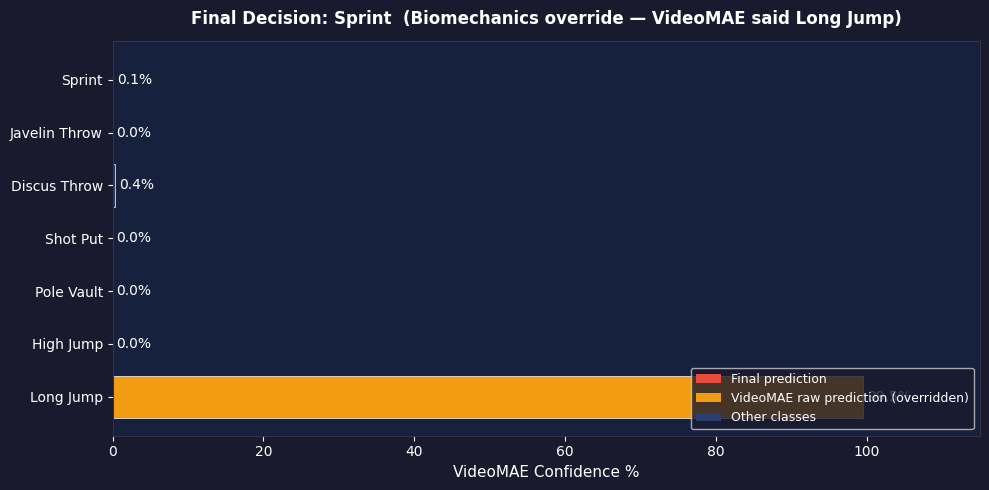


  DECISION SUMMARY
  VideoMAE prediction : Long Jump (99.5%)
  Biomechanics override → Sprint
  Reason: Sprint biomechanical signature detected



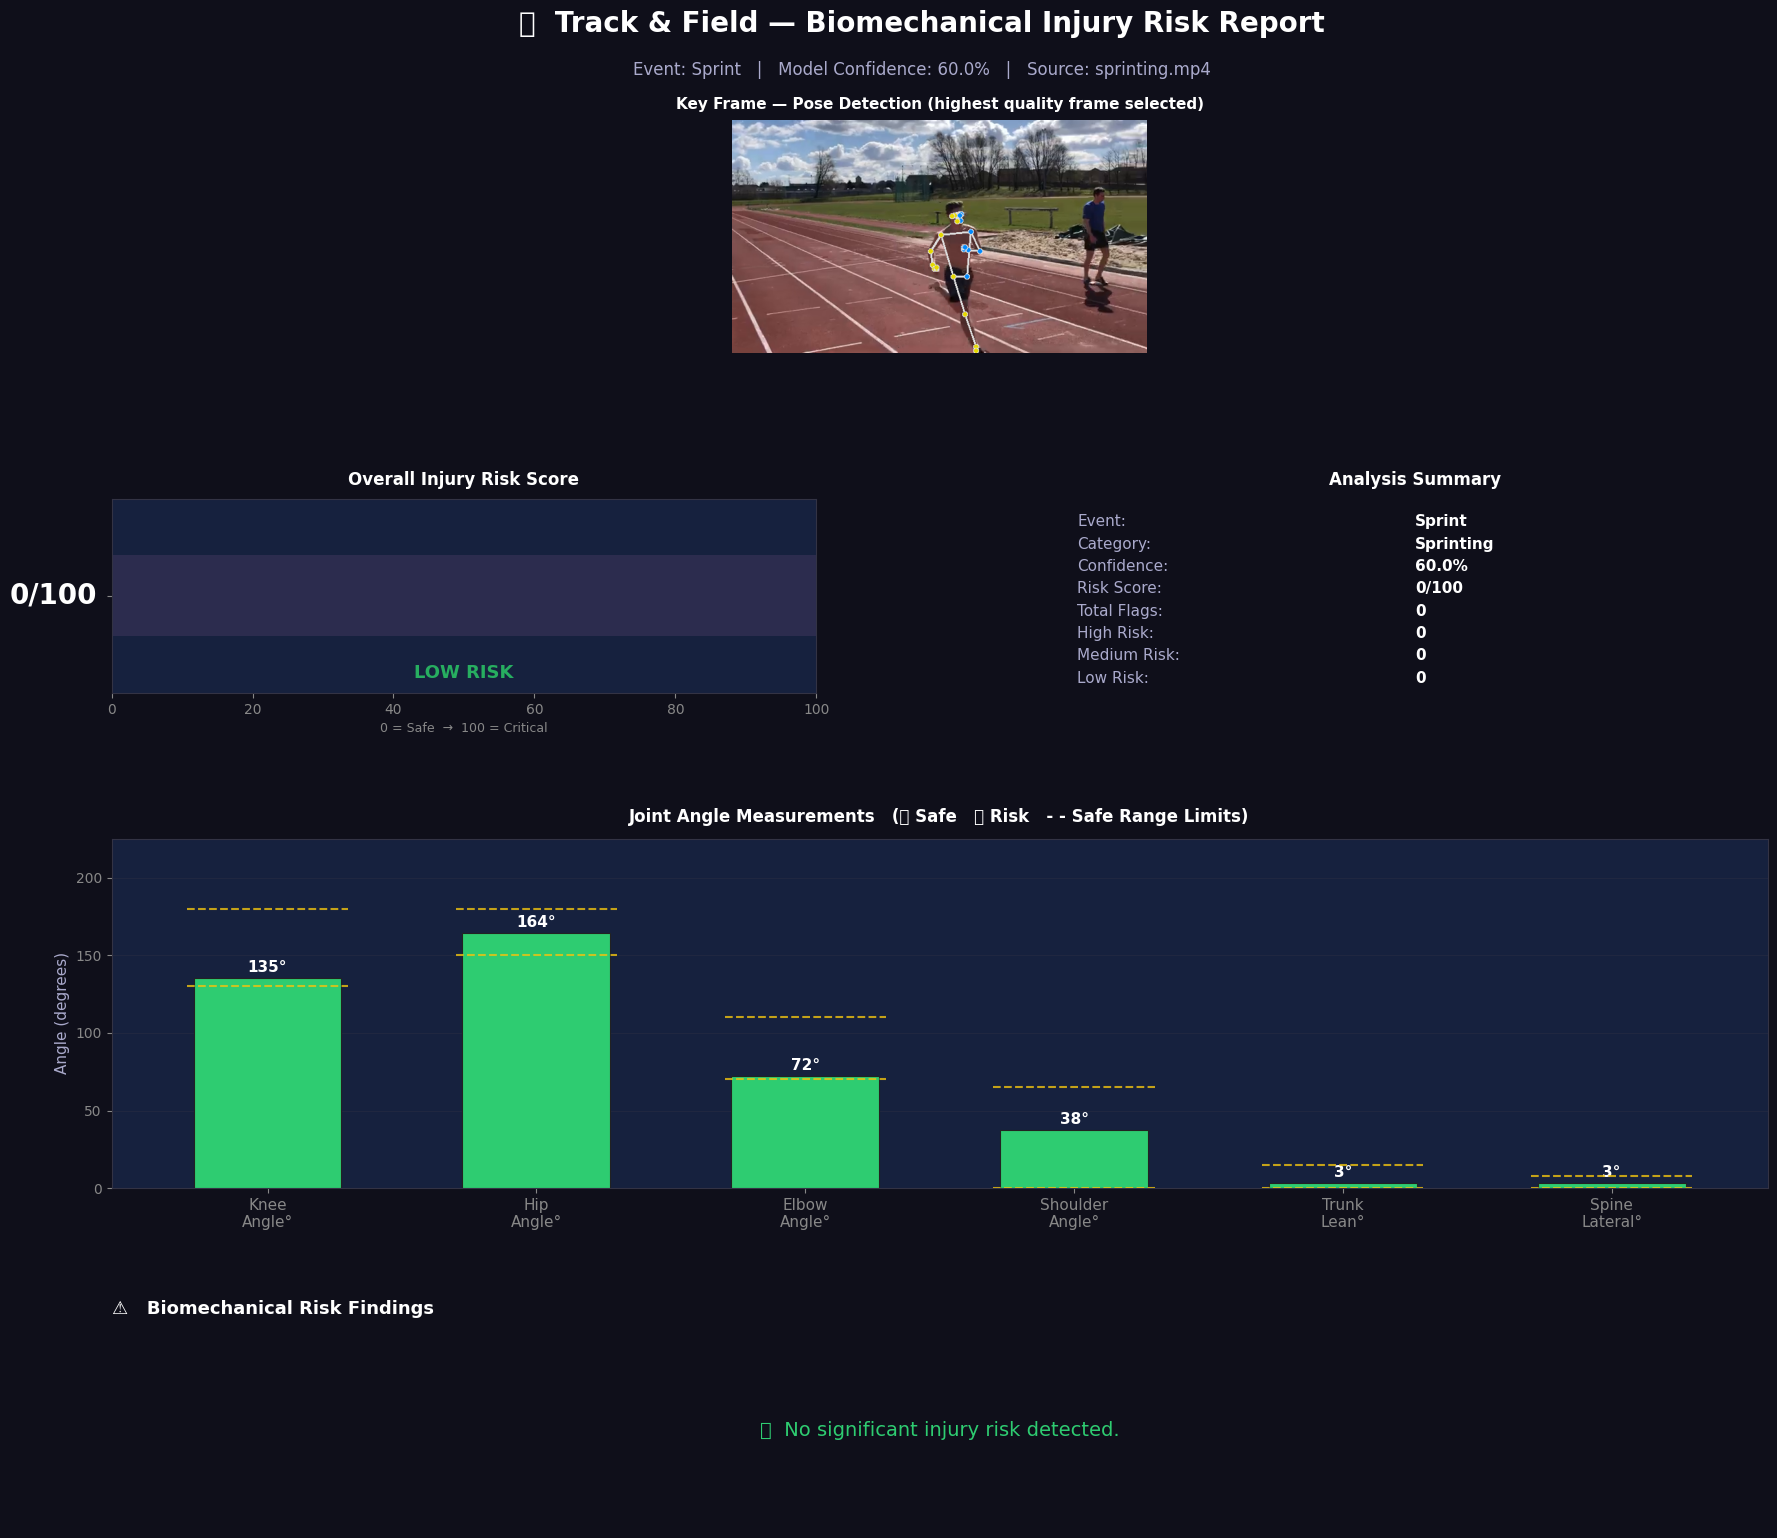

✅ Report saved → /kaggle/working/injury_risk_report.png


In [20]:
# ── Enter your video path here and run ────────────────────────────
VIDEO_PATH = '/kaggle/input/datasets/vishnu72005/sprinting/sprinting.mp4'

if os.path.exists(VIDEO_PATH):
    predict_and_analyse(VIDEO_PATH)
else:
    print(f"❌ Video not found at: {VIDEO_PATH}")
    print("\nTo find your video path, run this:")
    print("  import os")
    print("  for root, dirs, files in os.walk('/kaggle/input'):")
    print("      for f in files:")
    print("          print(os.path.join(root, f))")

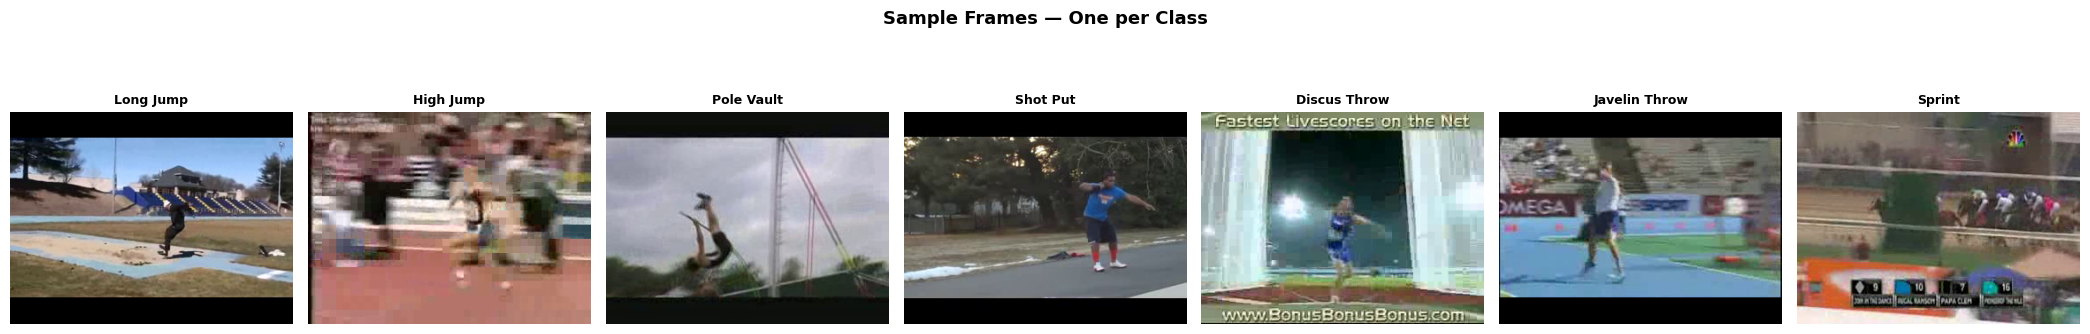

✅ Save this image for your submission


In [21]:
## getting sample images (ignore)
fig, axes = plt.subplots(1, 7, figsize=(21, 4))
fig.suptitle('Sample Frames — One per Class',
             fontsize=13, fontweight='bold')

for ax, (folder, (event_name, label, _)) in zip(
        axes, available.items()):
    clips = [f for f in os.listdir(
             os.path.join(ucf_root, folder))
             if f.endswith('.avi')]
    cap = cv2.VideoCapture(
        os.path.join(ucf_root, folder, clips[0]))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(event_name, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_frames_submission.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Save this image for your submission")